In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/apple-stock-price/AAPL.csv


In [43]:
import tensorflow as tf
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/apple-stock-price/AAPL.csv")
print(df.head())
prices = df['Close'].values
print(prices)

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.099319  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094137  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087228  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089387   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091978   73449600
[1.28348000e-01 1.21652000e-01 1.12723000e-01 ... 1.91240005e+02
 1.89429993e+02 1.93419998e+02]


In [91]:
print(prices.shape)
print(prices.reshape(-1, 1).shape)

(10836,)
(10836, 1)


In [90]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
print(scaler)
scaled_prices = scaler.fit_transform(prices.reshape(-1, 1))
print(scaled_prices)
print(scaled_prices.shape)

MinMaxScaler()
[[4.03465585e-04]
 [3.69372053e-04]
 [3.23908919e-04]
 ...
 [9.73472666e-01]
 [9.64256761e-01]
 [9.84572376e-01]]
(10836, 1)


In [74]:
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        a = i + seq_length
        x.append(data[i:a])
        y.append(data[a])
    return np.array(x), np.array(y)

In [85]:
seq_length = 60 
x, y = create_sequences(scaled_prices, seq_length)
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]
print(len(y))
print(len(x))
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
# x_train = x_train.reshape((x_train.shape[0], seq_length, 1))
# x_test = x_test.reshape((x_test.shape[0], seq_length, 1))

10776
10776
(8620, 60, 1)
(2156, 60, 1)
(8620, 1)
(2156, 1)


In [87]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(50, return_sequences = True))
model.add(tf.keras.layers.LSTM(50)),
model.add(tf.keras.layers.Dense(1))

In [88]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])

In [89]:
model.fit(x_train, y_train, epochs = 10, batch_size = 32, validation_data = (x_test, y_test))

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 2.3996e-05 - loss: 1.4748e-04 - val_accuracy: 4.6382e-04 - val_loss: 0.0036
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 1.3460e-04 - loss: 3.5577e-06 - val_accuracy: 4.6382e-04 - val_loss: 0.0027
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 5.6616e-06 - loss: 3.1890e-06 - val_accuracy: 4.6382e-04 - val_loss: 0.0021
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 6.0620e-05 - loss: 2.6975e-06 - val_accuracy: 4.6382e-04 - val_loss: 9.9317e-04
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 1.5226e-04 - loss: 3.3898e-06 - val_accuracy: 4.6382e-04 - val_loss: 0.0013
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 8.7163e-05 - loss: 2.6111e-06 - val_accuracy: 4.6382e-04 - val_loss: 0.0011
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 6.8038e-05 - loss: 3.2704e-06 - val_accuracy: 4.6382e-04 - val_loss: 5.2716e-0

In [92]:
prediction = model.predict(x_test)

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


In [93]:
prediction_inverse = scaler.inverse_transform(prediction)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

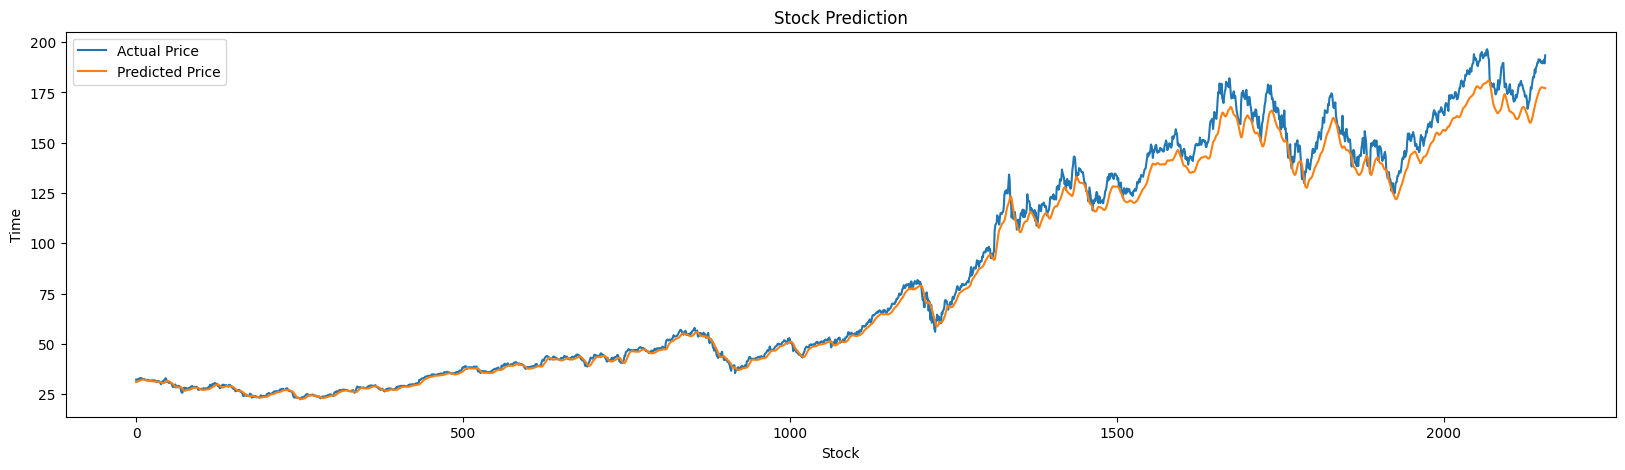

In [95]:
plt.figure(figsize = (20, 5))
plt.plot(y_test_inverse, label='Actual Price')
plt.plot(prediction_inverse, label = "Predicted Price")
plt.title('Stock Prediction')
plt.xlabel('Stock')
plt.ylabel('Time')
plt.legend()